# FRTB, end to end, with the heavy part on the GPU

**Ten stages, from a dated market snapshot to a signed capital number.**

This notebook is the Jupyter analogy of
[`demo/frtb-full-on-cuda.sh`](../demo/frtb-full-on-cuda.sh). Same Java code,
same ten stages, same numbers — but here the intermediate objects stay live in
the kernel, so you can poke at any of them.

The point of the exercise: in the FRTB standardised approach, **only one stage
is computationally expensive** — the shocked full repricing that feeds
curvature. Everything else (weighting, correlations, DRC, RRAO) is scalar
arithmetic over a few hundred numbers. This notebook times both so the
difference is visible rather than asserted.

> The parameter tables, sample trades and sign-off roles are **illustrative
> demo data** living in `FrtbFullShowcase`. This is a compute demonstration,
> not a regulatory implementation, and nothing here is a filing.

In [1]:
import os

# JPype needs a JDK 24+ home; the project builds on 25/26.
os.environ.setdefault("NABLATENSOR_JDK", "/opt/zulu26.32.13-ca-jdk26.0.2-linux_x64")

import nablatensor as nt

nt.start()  # boots one JVM against the checkout's */target/classes

for e in nt.engines():
    print(f"  {'ok' if e['available'] else '--':>3}  {e['name']:<12} {e['describe']}")

available = {e["name"] for e in nt.engines() if e["available"]}
ENGINE = "cuda" if "cuda" in available else nt.best_engine()
FP32 = ENGINE in {"cuda", "vulkan", "rocm"}
PATHS = 2_000_000 if FP32 else 250_000
STEPS, SEED, SHORT = 252, 42, -1.0

print(f"\nengine {ENGINE}   {'fp32' if FP32 else 'fp64'}   {PATHS:,} paths x {STEPS} fixings")

   ok  cuda         CUDA · Quadro T2000 · compute_75
   ok  cuda-interp  CUDA interpreter · Quadro T2000 · no per-tape compilation
   ok  cuda-eager   CUDA eager, one launch per node · Quadro T2000
   --  vulkan       Vulkan compute unavailable
   --  rocm         ROCm/HIP · no device
   ok  simd         Vector API · S_256_BIT, 4x fp64 / 8x fp32 per vector, batch 32 · 12 processors · fp32+fp64
   ok  cpu          scalar JVM · 12 processors · fp64
   ok  cpu-jit      generated straight-line bytecode kernel · RNG prefilled · segmented for C2 · fp32+fp64

engine cuda   fp32   2,000,000 paths x 252 fixings


In [2]:
# The Java types this notebook drives. `nt.jclass` is the escape hatch for
# anything the bridge does not re-export by name.
Showcase = nt.jclass("com.nablatensor.examples.FrtbFullShowcase")
SignOff = nt.jclass("com.nablatensor.examples.FrtbFullShowcase$SignOff")
RiskClass = nt.jclass("com.nablatensor.risk.RiskClass")
RiskMeasure = nt.jclass("com.nablatensor.risk.RiskMeasure")
RiskFactor = nt.jclass("com.nablatensor.risk.RiskFactor")
NestedAggregation = nt.jclass("com.nablatensor.risk.NestedAggregation")
Corr = nt.jclass("com.nablatensor.risk.CorrelationScenario")
ScenarioSet = nt.jclass("com.nablatensor.scenario.ScenarioSet")
Scenario = nt.jclass("com.nablatensor.scenario.Scenario")
Shock = nt.jclass("com.nablatensor.scenario.Shock")
ScenarioRunner = nt.jclass("com.nablatensor.scenario.ScenarioRunner")

LOW, MEDIUM, HIGH = Corr.LOW, Corr.MEDIUM, Corr.HIGH
CLASSES = list(RiskClass.values())


def row(label, value):
    """The notebook's stand-in for the shell demo's row() helper."""
    print(f"   {label:<26} {value:>12,.4f}")

## 1 · Load the market, the trades, the rulebook

Nothing is calculated before the inputs are dated and counted. A market
snapshot, a trade file, and a **versioned** parameter set — the three things
an auditor asks for first.

In [3]:
params = Showcase.parameters()
market = Showcase.marketData()
trades = Showcase.trades()

print(f"   as of {market.asOf()}   {len(market.levels())} curves   "
      f"{len(trades)} trades   {params.bucketCount()} buckets")
print(f"   parameter set {params.version()}\n")

for name, level in market.levels().items():
    print(f"   market  {str(name):<16} {float(level):>10.5f}")
print()
for t in trades:
    print(f"   trade   {str(t.id()):<12} {str(t.nettingSet()):<11} "
          f"side {t.side():+.0f}   notional ${t.notional() / 1e6:.1f}m")

   as of 2026-09-02   6 curves   3 trades   89 buckets
   parameter set DEMO-MAR21-2026-09

   market  EURUSD              1.08500
   market  IMPLIED-VOL         0.20000
   market  WTI-1Y             76.50000
   market  SPX               100.00000
   market  ACME-SPREAD-5Y      0.01200
   market  USD-OIS-5Y          0.04200

   trade   ASIAN-001    NS-OPTIONS  side -1   notional $12.0m
   trade   ASIAN-HEDGE  NS-OPTIONS  side +1   notional $4.5m
   trade   MACRO-HEDGE  NS-MACRO    side +1   notional $8.0m


## 2 · The regulatory parameter tables

Seven risk classes, 89 buckets. Every bucket carries a delta risk weight, a
vega risk weight, a within-bucket correlation `rho` and an across-bucket
correlation `gamma`.

In [4]:
for rc in CLASSES:
    print(f"   {str(rc):<12} {len(params.tables().get(rc)):>2} buckets")

print("\n   equity table:")
for bucket, p in params.tables().get(RiskClass.EQUITY).items():
    print(f"     bucket {str(bucket):<3} deltaRw={p.deltaRw():.3f}  "
          f"vegaRw={p.vegaRw():.3f}  rho={p.rho():.3f}  gamma={p.gamma():.3f}")

   GIRR          3 buckets
   CSR_NON_SEC  18 buckets
   CSR_SEC      25 buckets
   CSR_SEC_CTP  16 buckets
   EQUITY       13 buckets
   COMMODITY    11 buckets
   FX            3 buckets

   equity table:
     bucket 1   deltaRw=0.550  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 2   deltaRw=0.600  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 3   deltaRw=0.450  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 4   deltaRw=0.550  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 5   deltaRw=0.300  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 6   deltaRw=0.350  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 7   deltaRw=0.400  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 8   deltaRw=0.500  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 9   deltaRw=0.700  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 10  deltaRw=0.500  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 11  deltaRw=0.700  vegaRw=1.000  rho=0.250  gamma=0.150
     bucket 12  deltaRw=0.150  vegaRw=1.000  

## 3 · Delta: one adjoint sweep

The book's equity option is a **short Asian call** — 252 daily fixings, so its
payoff depends on the whole path, and there is no closed form to fall back on.

It is recorded once and differentiated in a single reverse sweep. Delta is
cheap. What follows is not.

In [5]:
mkt = nt.EquityMarket.atmOneYear()
asian = nt.Products.asianCall()


def monte_carlo(mode):
    """One builder for both kernels: adjoint greeks, or price-only replay."""
    b = nt.MonteCarlo.of(asian).market(mkt).steps(STEPS)
    b = b.fp32() if FP32 else b.fp64()
    b = b.greeks() if mode == "greeks" else b.priceOnly()
    return b.on(ENGINE).build()


aad = monte_carlo("greeks")
aad.run(50_000, SEED)  # warm-up: compile and page in, not measured
risk = aad.run(mkt, PATHS, SEED)

delta = SHORT * risk.greeks().spot()  # same as risk.greek(lambda m: m.spot())
row("delta", delta)
row("adjoint seconds", risk.seconds())

   delta                           -0.5619
   adjoint seconds                  0.1561


## 4 · THE HEAVY PART: base / +30% / −30% full repricings

Curvature is not a derivative. The regulation asks for the **actual P&L** after
a large prescribed shock, so the whole portfolio must be priced again at spot
+30% and −30%.

One compiled kernel, three complete replays, the same random numbers in each
(common random numbers — otherwise the differences below would be Monte Carlo
noise rather than convexity).

In [6]:
pricer = monte_carlo("price")
pricer.run(50_000, SEED)

shocks = ScenarioSet.list(
    Scenario.of("base"),
    Scenario.of("up", Shock.relative("spot", 0.30)),
    Scenario.of("down", Shock.relative("spot", -0.30)),
)
pv = ScenarioRunner.run(pricer, mkt, shocks, PATHS, SEED)

print(f"   {'replay':<8} {'long PV':>12} {'seconds':>9} {'throughput':>13}")
for label in ("base", "up", "down"):
    v = pv.get(label)
    print(f"   {label:<8} {v.price():>12.6f} {v.seconds():>9.3f} "
          f"{v.scenariosPerSecond():>13.2e}")

pair_seconds = pv.get("up").seconds() + pv.get("down").seconds()
print("\n   a 10,000-factor book needs 2 replays per factor:")
print(f"   ~{10_000 * pair_seconds / 60:.1f} min sequential on this machine")

   replay        long PV   seconds    throughput
   base         5.301626     0.029      7.00e+07
   up          31.063044     0.029      6.83e+07
   down         0.006292     0.029      6.81e+07

   a 10,000-factor book needs 2 replays per factor:
   ~9.8 min sequential on this machine


## 5 · Strip the linear P&L: CVR

Curvature keeps only the loss that delta could **not** explain:

$$\text{CVR} = -\min\Big(\underbrace{PV^{up} - PV - s\,\delta}_{\text{up residual}},\;
                         \underbrace{PV^{down} - PV + s\,\delta}_{\text{down residual}}\Big)$$

The regulation takes the worse of the two sides.

The prices above are the option's own PV. The book is **short** it, so every
number below carries `SHORT`.

In [7]:
base = SHORT * pv.get("base").price()
up = SHORT * pv.get("up").price()
down = SHORT * pv.get("down").price()
shock = 0.30 * mkt.spot()

up_residual = up - base - shock * delta
down_residual = down - base + shock * delta
cvr = -min(up_residual, down_residual)

row("base PV", base)
row("PV at spot +30%", up)
row("PV at spot -30%", down)
row("up residual", up_residual)
row("down residual", down_residual)
row("CVR", cvr)

   base PV                         -5.3016
   PV at spot +30%                -31.0630
   PV at spot -30%                 -0.0063
   up residual                     -8.9036
   down residual                  -11.5625
   CVR                             11.5625


## 6 · Map trades to risk factors, then net

Each trade carries its own sensitivity vector. Netting is plain addition on the
**shared regulatory factor keys** — trade, then netting set, then book. The
CUDA curvature number computed above enters as one equity bucket-5 factor.

In [8]:
portfolio = Showcase.buildPortfolio(trades, params, market, cvr)
netted = portfolio.aggregate()

observations = sum(len(t.sensitivities().asMap()) for t in portfolio.trades())
print(f"   {observations} trade observations -> {len(netted.asMap())} net factors\n")

for name, sens in portfolio.byNettingSet().items():
    print(f"   {str(name):<12} {len(sens.asMap()):>4} factors")

asian_cvr = RiskFactor.equityDelta("5", "ASIAN-001").asCurvature()
print(f"\n   the CUDA CVR, now in the book: {netted.get(asian_cvr):.6f}")

   802 trade observations -> 268 net factors

   NS-OPTIONS    268 factors
   NS-MACRO      267 factors

   the CUDA CVR, now in the book: 11.562528


## 7 · Weight, correlate, and run LOW / MEDIUM / HIGH

`WS = RW × s`, aggregated inside each bucket, then across buckets. FRTB runs
the whole aggregation **three times** under prescribed correlation scenarios
and keeps whichever hurts most.

The lambdas below are Python functions satisfying the Java functional
interfaces — JPype passes them straight into the aggregation engine.

In [9]:
eq_table = params.tables().get(RiskClass.EQUITY)
eq_delta = netted.ofClass(RiskClass.EQUITY).ofMeasure(RiskMeasure.DELTA)

for sc in Corr.values():
    agg = NestedAggregation.delta(
        lambda k: eq_table.get(k.bucket()).deltaRw(),
        lambda k, l, sc=sc: 1.0 if k.equals(l) else sc.apply(eq_table.get(k.bucket()).rho()),
        lambda b, c, sc=sc: 1.0 if b == c else sc.apply(0.15),
    )
    row(f"equity delta {sc}", agg.aggregate(eq_delta).total())

   equity delta MEDIUM             10.7829
   equity delta HIGH               10.5747
   equity delta LOW                10.9871


In [10]:
capital = Showcase.aggregate(params, netted)


def scen_row(label, m):
    print(f"     {label:<10} L {float(m.scenarios().get(LOW)):>8.3f}  "
          f"M {float(m.scenarios().get(MEDIUM)):>8.3f}  "
          f"H {float(m.scenarios().get(HIGH)):>8.3f}  ->  "
          f"{str(m.selected()):<6} {m.total():>8.3f}")


for rc in CLASSES:
    c = capital.byClass().get(rc)
    print(f"   {rc}")
    scen_row("delta", c.delta())
    scen_row("vega", c.vega())
    scen_row("curvature", c.curvature())
    print(f"     {'subtotal':<10} {c.total():>52.3f}")

   GIRR
     delta      L    0.007  M    0.007  H    0.006  ->  LOW       0.007
     vega       L    1.169  M    1.249  H    1.325  ->  HIGH      1.325
     curvature  L    0.529  M    0.554  H    0.585  ->  HIGH      0.585
     subtotal                                                  1.917
   CSR_NON_SEC
     delta      L    0.016  M    0.015  H    0.013  ->  LOW       0.016
     vega       L    5.344  M    6.043  H    6.669  ->  HIGH      6.669
     curvature  L    1.379  M    1.588  H    1.821  ->  HIGH      1.821
     subtotal                                                  8.506
   CSR_SEC
     delta      L    0.016  M    0.015  H    0.013  ->  LOW       0.016
     vega       L    7.302  M    8.302  H    9.194  ->  HIGH      9.194
     curvature  L    1.713  M    2.017  H    2.351  ->  HIGH      2.351
     subtotal                                                 11.561
   CSR_SEC_CTP
     delta      L    0.024  M    0.022  H    0.020  ->  LOW       0.024
     vega       L    4.7

## 8 · Default risk charge

Jump-to-default nets by obligor. A **hedge benefit ratio** then limits how much
the short positions may offset the longs.

In [11]:
jtd = Showcase.defaultPositions()
for p in jtd:
    print(f"   {str(p.obligor()):<10} JTD {p.jumpToDefault() / 1e6:>7.2f}m   RW {p.riskWeight():.3f}")

drc = Showcase.defaultRiskCharge(jtd)
hbr = drc.longs() / (drc.longs() + drc.shorts())
drc_charge = max(drc.weightedLongs() - hbr * drc.weightedShorts(), 0.0)

print()
row("net JTD long ($m)", drc.longs())
row("net JTD short ($m)", drc.shorts())
row("hedge benefit ratio", hbr)
row("DRC ($m)", drc_charge)

   ACME       JTD    3.50m   RW 0.030
   ACME       JTD   -1.10m   RW 0.030
   SMALLCO    JTD   -0.20m   RW 0.150
   SOVEREIGN  JTD    2.00m   RW 0.005

   net JTD long ($m)                4.4000
   net JTD short ($m)               0.2000
   hedge benefit ratio              0.9565
   DRC ($m)                         0.0533


## 9 · Residual risk add-on

A flat gross-notional surcharge for what SBM and DRC cannot capture: 1.0% on
exotic underlyings, 0.1% on everything else in scope. No netting, no
correlations — a weighted sum.

In [12]:
residual = Showcase.residualPositions(trades)
exotic = sum(abs(p.grossNotional()) / 1e6 * 0.010 for p in residual if p.exotic())
other = sum(abs(p.grossNotional()) / 1e6 * 0.001 for p in residual if not p.exotic())

for p in residual:
    kind = "exotic 1.0%" if p.exotic() else "other 0.1%"
    print(f"   {str(p.id()):<16} ${abs(p.grossNotional()) / 1e6:>6.1f}m   {kind}")

print()
row("RRAO exotic ($m)", exotic)
row("RRAO other ($m)", other)

   ASIAN-001        $  12.0m   other 0.1%
   WEATHER-OPTION   $   2.0m   exotic 1.0%

   RRAO exotic ($m)                 0.0200
   RRAO other ($m)                  0.0120


## 10 · Capital bridge, controls, sign-off

The three charges add with no diversification between them.

In [13]:
rrao = Showcase.residualRiskAddOn(residual)
sbm = capital.total()
total = sbm + drc.total() + rrao.total()

row("SBM ($m)", sbm)
row("DRC ($m)", drc.total())
row("RRAO ($m)", rrao.total())
row("FRTB total ($m)", total)

sign_off = SignOff.review(params, market, portfolio, capital, drc, rrao)
print()
for control in sign_off.controls():
    print(f"   [PASS] {control}")
print()
for role, who in sign_off.approvers().items():
    print(f"   {str(role):<18} {who}")
print(f"\n   {sign_off.status()}")
print("   Educational evidence package; not a regulatory filing.")

   SBM ($m)                        70.0370
   DRC ($m)                         0.0533
   RRAO ($m)                        0.0320
   FRTB total ($m)                 70.1223

   [PASS] market snapshot is dated and non-empty
   [PASS] all seven parameter tables and 89 buckets are present
   [PASS] trade and netting-set lineage is retained
   [PASS] LOW/MEDIUM/HIGH results exist for delta, vega, and curvature
   [PASS] DRC and RRAO are non-negative

   Model owner        A. Quant (demo)
   Risk control       B. Controller (demo)
   Regulatory owner   C. Officer (demo)

   APPROVED FOR DEMO
   Educational evidence package; not a regulatory filing.


## The two pictures

**Left:** where the capital comes from — delta, vega and curvature per risk
class, at the correlation scenario each one selected.

**Right:** what curvature actually measures. The same compiled kernel is
replayed across a spot ladder (no rebuild — the market is a kernel argument).
The straight line is the delta approximation; the gap between the curve and
that line at ±30% is the non-linear residual the CVR keeps.

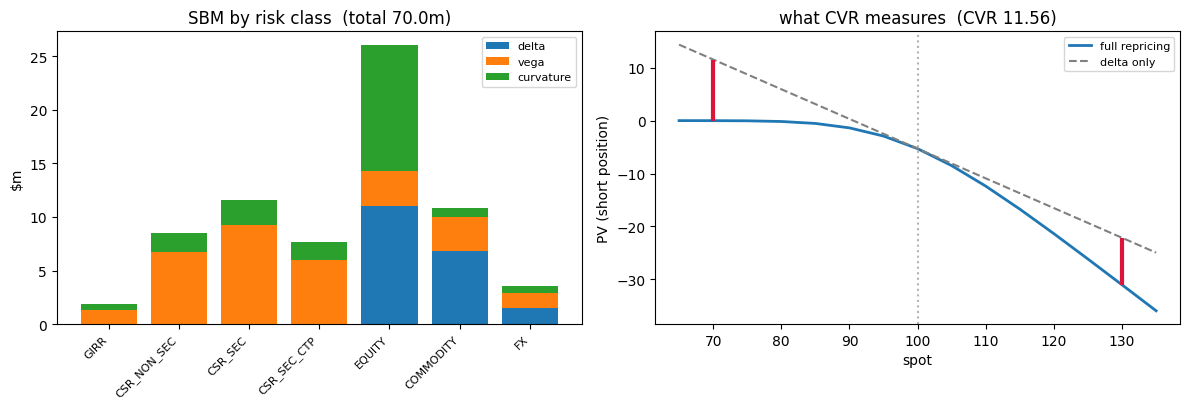

In [14]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    fig, (ax_c, ax_k) = plt.subplots(1, 2, figsize=(12, 4.2))

    names = [str(rc) for rc in CLASSES]
    d = [capital.byClass().get(rc).delta().total() for rc in CLASSES]
    v = [capital.byClass().get(rc).vega().total() for rc in CLASSES]
    k = [capital.byClass().get(rc).curvature().total() for rc in CLASSES]
    x = np.arange(len(names))

    ax_c.bar(x, d, label="delta")
    ax_c.bar(x, v, bottom=d, label="vega")
    ax_c.bar(x, k, bottom=np.add(d, v), label="curvature")
    ax_c.set_xticks(x)
    ax_c.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax_c.set_ylabel("$m")
    ax_c.set_title(f"SBM by risk class  (total {sbm:,.1f}m)")
    ax_c.legend(fontsize=8)

    fractions = np.linspace(-0.35, 0.35, 15)
    ladder = [SHORT * pricer.run(mkt.withSpot(mkt.spot() * (1 + f)), PATHS // 8, SEED).price()
              for f in fractions]
    spots = mkt.spot() * (1 + fractions)
    tangent = [base + delta * (s - mkt.spot()) for s in spots]

    ax_k.plot(spots, ladder, lw=2, label="full repricing")
    ax_k.plot(spots, tangent, ls="--", c="0.5", label="delta only")
    for s, lo, hi in ((mkt.spot() * 1.3, up, base + delta * shock),
                      (mkt.spot() * 0.7, down, base - delta * shock)):
        ax_k.vlines(s, min(lo, hi), max(lo, hi), color="crimson", lw=3)
    ax_k.axvline(mkt.spot(), ls=":", c="0.7")
    ax_k.set_xlabel("spot")
    ax_k.set_ylabel("PV (short position)")
    ax_k.set_title(f"what CVR measures  (CVR {cvr:,.2f})")
    ax_k.legend(fontsize=8)

    fig.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib/numpy not installed - skipping the plots")

## What this run showed

| | |
|---|---|
| Expensive | one adjoint sweep + **three full Monte-Carlo repricings** |
| Cheap | 89 bucket weights, 21 correlation aggregations, DRC, RRAO, sign-off |

Two shocked repricings per curvature factor is the whole cost story of FRTB
curvature. A real book has thousands of factors, which is why this stage is
distributed across a compute grid — and why moving one replay from CPU to GPU
is worth doing.

The regulatory arithmetic after it, all seven risk classes and three
correlation scenarios of it, ran in the time between two of these cells.

In [ ]:
aad.close()
pricer.close()
print("kernels released")